In [1]:
import jax
from jax import numpy as jnp
import numpy as np
import einops

import equinox as eqx
from equinox.nn import Linear

from typing import Optional
from jaxtyping import Float, Array, PRNGKeyArray

from jepax.model.masker import set_token_mask
from jepax.model.transformer import Transformer, PositionalEncoding
from jepax.model.vit import PatchEmbedding

class IJEPAEncoder(eqx.Module):
    embed: PatchEmbedding
    transformer: Transformer

    def __init__(
        self,
        num_channels: int,
        patch_size: int,
        dim: int,
        num_layers: int,
        num_head: int,
        mlp_ratio: float = 3.0,
        p_drop: float = 0.1,
        seq_len: int = 2048,
        *,
        key: PRNGKeyArray
    ):
        k1, k2, k3 = jax.random.split(key, 3)

        self.embed = PatchEmbedding(num_channels, dim, patch_size, k1)
        self.transformer = Transformer(
            dim=dim, 
            num_layers=num_layers,
            num_head=num_head,
            mlp_ratio=mlp_ratio,
            p_drop=p_drop,
            seq_len=seq_len,
            key=k2
        )
        self.ctx_mask = jax.random.normal(k3, (1, dim))


    def __call__(self, key, x, mask=None, train=True):
        x = self.embed(x)
        if mask:
            x = set_token_mask(x, mask, self.ctx_mask)

        x = self.transformer(x, key=key, train=train)
        return x
    
class IJEPAPredictor(eqx.Module):
    in_proj: eqx.nn.Linear
    out_proj: eqx.nn.Linear
    transformer: Transformer
    num_mask: int = eqx.field(static=True)

    def __init__(
        self,
        latent_dim: int,
        dim: int,
        num_layers: int,
        num_head: int,
        num_mask: int,
        mlp_ratio: float = 3.0,
        p_drop: float = 0.1,
        seq_len: int = 2048,
        *,
        key: PRNGKeyArray
    ):
        k1, k2, k3, k4 = jax.random.split(key, 4)

        self.num_mask = num_mask

        self.in_proj = eqx.nn.Linear(latent_dim, dim, key=k1)
        self.transformer = Transformer(
            dim=dim, 
            num_layers=num_layers,
            num_head=num_head,
            mlp_ratio=mlp_ratio,
            p_drop=p_drop,
            seq_len=seq_len,
            key=k2
        )
        self.mask_token = jax.random.normal(k3, (1, dim))
        self.out_proj = eqx.nn.Linear(dim, latent_dim, key=k4)
        self.pe = PositionalEncoding(dim=dim, seq_len=seq_len)

    def __call__(self, key, x: Float[Array, "T D"], mask_pred: Float[Array, "Bm T D"], train=True):
        x = self.pe(x)
        num_mask = mask_pred.shape[0]
        x = jnp.repeat(x[None], num_mask, axis=0)

        x = self.transformer(x, key=key, train=train, use_pe=False)

        return x

In [2]:
from functools import partial
import matplotlib.pyplot as plt

from jepax.data import build_dataset
from jepax.model.masker import IJEPAMasker

dataloader, _, _, _ = build_dataset("CIFAR10", data_dir="~/data")
x, y = next(iter(dataloader))

/Users/anton/source/jepax/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


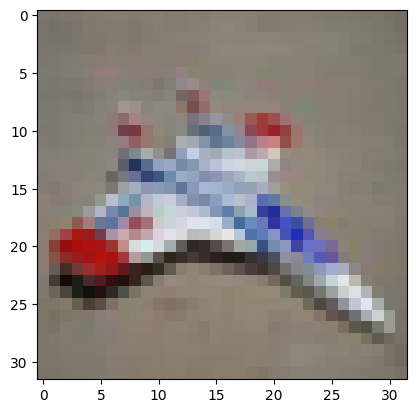

In [3]:
x_in = x[-2]
plt.imshow(x_in)

In [4]:
masker = IJEPAMasker(32, 32, 2, ctx_scale=0.8, ctx_aspect=1.5, pred_scale=0.175, pred_aspect=1.0)
M = 4

@partial(jax.jit, static_argnums=(1,2))
def create_mask(key, M, flatten):
    return masker(key, M, flatten=True)

key = jax.random.PRNGKey(11)
mask_ctx, mask_pred = create_mask(key, M, True)

print(mask_ctx.shape, mask_pred.shape)

JitTracer<float32[]>
JitTracer<float32[]>
JitTracer<float32[]>
(256,) (4, 256)


In [5]:
masker._get_idx_mask(0.8, 1.5)

0.8


(Array(16., dtype=float32, weak_type=True),
 Array(8., dtype=float32, weak_type=True),
 Array(8., dtype=float32, weak_type=True),
 Array(12., dtype=float32, weak_type=True))

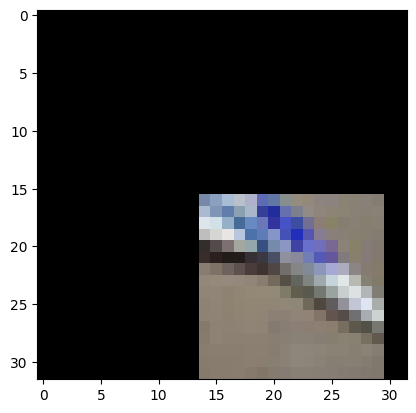

In [7]:
def patchify(x, patch_size=2):
    return einops.rearrange(
        x,
        "(h ph) (w pw) c -> (h w) (c ph pw)",
        ph=patch_size,
        pw=patch_size,
    )

def unpatchify(x, patch_size=2, n_patch=16):
    return einops.rearrange(
        x,
        "(h w) (c ph pw) -> (h ph) (w pw) c",
        h=n_patch,
        ph=patch_size,
        pw=patch_size,
    )

def visualize_mask(x, mask):
    x_masked = jax.vmap(lambda x, m: x * m)(patchify(x), mask)
    x_masked_img = unpatchify(x_masked)
    return x_masked_img

plt.imshow(visualize_mask(x_in, mask_ctx))